# Day 2: Answer Key
### Multi-dimensional systems and epidemic models

Worked solutions for the three **"you try"** exercises (1 to 3) in the Session 3 epidemic-models block, mirroring `Day2_revised_realdata_executed.ipynb`. Every model uses the same forward-Euler loop, with transmission written in the frequency-dependent form $\beta S I / N$, and each build keeps the population conserved (the sum-to-$N$ self-check stays flat).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The same simulate() helper used in the participant notebook: hand it a rate
# function, a starting state, and the parameters, and it runs the Euler loop.
def simulate(rhs, x0, par, days=200, delta_t=0.1):
    ts = np.arange(0, days + delta_t, delta_t)
    xs = np.zeros((len(ts), len(x0)))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(1, len(ts)):
        xs[k] = xs[k - 1] + delta_t * rhs(xs[k - 1], par)
    return ts, xs

## Exercise 1: SIR and the $R_0$ threshold

**Core:** with $\beta$ fixed at 0.3, the outbreak stops taking off when $\gamma$ reaches 0.3, because $R_0 = \beta/\gamma = 1$ there. Below that ($\gamma < 0.3$) the epidemic grows; above it ($\gamma > 0.3$) it fizzles out. The sweep below shows the Infected curve flattening as $\gamma$ climbs through the threshold.

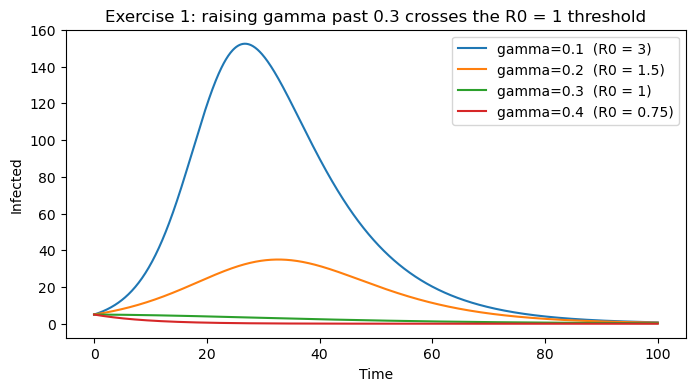

In [2]:
def sir_rhs(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    return np.array([-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I])

plt.figure(figsize=(8, 4))
for gamma in [0.1, 0.2, 0.3, 0.4]:
    ts, xs = simulate(sir_rhs, np.array([495., 5., 0.]), (0.3, gamma), days=100)
    R0 = 0.3 / gamma
    plt.plot(ts, xs[:, 1], label=f"gamma={gamma}  (R0 = {R0:.2g})")
plt.xlabel("Time"); plt.ylabel("Infected")
plt.title("Exercise 1: raising gamma past 0.3 crosses the R0 = 1 threshold")
plt.legend(); plt.show()

## Exercise 2: extend the SIR model (add one compartment)

The participant workspace (`my_rhs`) starts as plain SIR; any single new box with its arrows is a correct answer, as long as the population still sums to $N$. Below are the three steers from the notebook, each **one new box with one or two new arrows**, and each conserves the population:

- **SIRD (Deaths):** split the outflow from $I$ into recoveries ($\gamma I$) and deaths ($\mu I$).
- **SIRV (Vaccinated):** one new arrow $\nu S$ out of $S$ into a new box $V$.
- **SEIR (Exposed):** insert $E$ between $S$ and $I$; infection now flows $S \to E$, and $E \to I$ at rate $\varepsilon$.

The **SIHR** hospitalization model is a fourth worked example (a Hospitalized box, splitting the outflow from $I$), shown right after.

SIRD: final deaths = 74.6 | population sum = 500.0


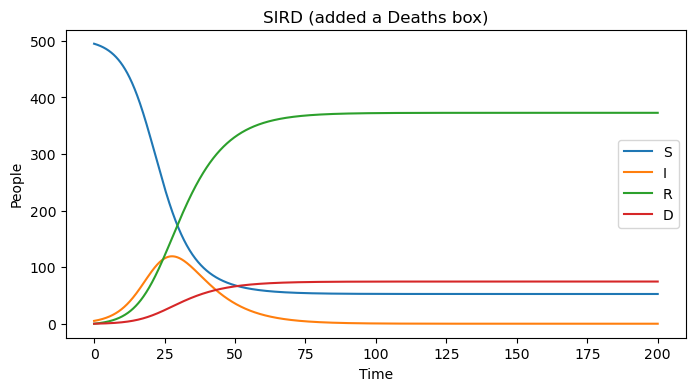

SIRV: final vaccinated = 262.1 | peak I = 65.8 | population sum = 500.0


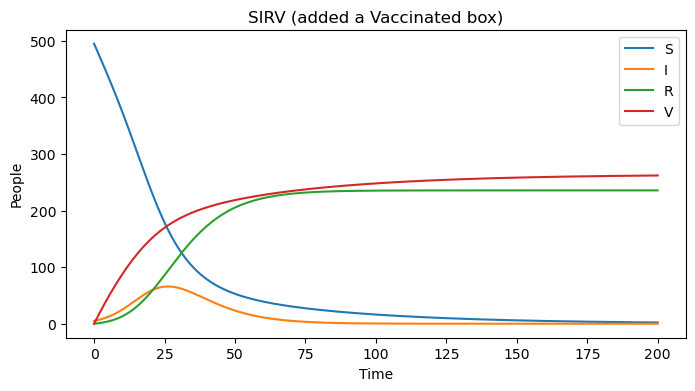

SEIR: peak I = 99.6 | population sum = 500.0


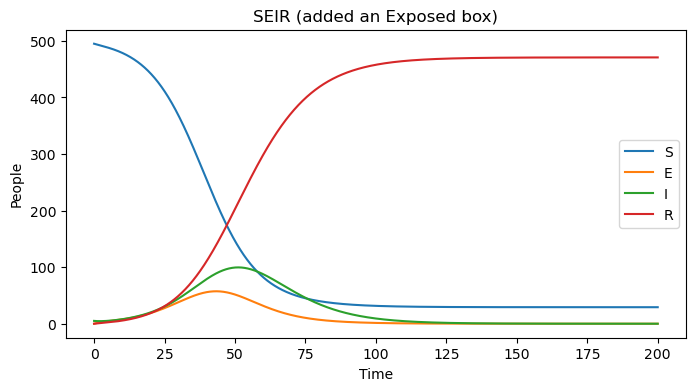

In [3]:
# SIRD: add a Deaths box. The outflow from I splits into gamma*I (recover) and mu*I (die).
def sird_rhs(X, params):
    S, I, R, D = X; N = X.sum(); beta, gamma, mu = params
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I - mu * I
    dR =  gamma * I
    dD =  mu * I
    return np.array([dS, dI, dR, dD])

ts, xs = simulate(sird_rhs, np.array([495., 5., 0., 0.]), (0.3, 0.1, 0.02))
print("SIRD: final deaths =", round(xs[-1, 3], 1), "| population sum =", round(xs[-1].sum(), 1))
plt.figure(figsize=(8, 4)); plt.plot(ts, xs, label=["S", "I", "R", "D"]); plt.legend()
plt.title("SIRD (added a Deaths box)"); plt.xlabel("Time"); plt.ylabel("People"); plt.show()

# SIRV: add a Vaccinated box. Susceptibles are vaccinated at rate nu (a new arrow out of S).
def sirv_rhs(X, params):
    S, I, R, V = X; N = X.sum(); beta, gamma, nu = params
    dS = -beta * S * I / N - nu * S
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    dV =  nu * S
    return np.array([dS, dI, dR, dV])

ts, xs = simulate(sirv_rhs, np.array([495., 5., 0., 0.]), (0.3, 0.1, 0.02))
print("SIRV: final vaccinated =", round(xs[-1, 3], 1), "| peak I =", round(xs[:, 1].max(), 1), "| population sum =", round(xs[-1].sum(), 1))
plt.figure(figsize=(8, 4)); plt.plot(ts, xs, label=["S", "I", "R", "V"]); plt.legend()
plt.title("SIRV (added a Vaccinated box)"); plt.xlabel("Time"); plt.ylabel("People"); plt.show()

# SEIR: insert an Exposed box between S and I. Infection flows S -> E, then E -> I at rate epsilon.
def seir_rhs(X, params):
    S, E, I, R = X; N = X.sum(); beta, epsilon, gamma = params
    dS = -beta * S * I / N
    dE =  beta * S * I / N - epsilon * E
    dI =  epsilon * E - gamma * I
    dR =  gamma * I
    return np.array([dS, dE, dI, dR])

ts, xs = simulate(seir_rhs, np.array([495., 0., 5., 0.]), (0.3, 0.2, 0.1))
print("SEIR: peak I =", round(xs[:, 2].max(), 1), "| population sum =", round(xs[-1].sum(), 1))
plt.figure(figsize=(8, 4)); plt.plot(ts, xs, label=["S", "E", "I", "R"]); plt.legend()
plt.title("SEIR (added an Exposed box)"); plt.xlabel("Time"); plt.ylabel("People"); plt.show()

### SIHR: a fourth worked example

The SIHR model adds a Hospitalized box by splitting the outflow from $I$. Writing the compartments in order $S, I, H, R$:

$$
\begin{aligned}
\frac{dS}{dt} &= -\frac{\beta S I}{N} \\
\frac{dI}{dt} &= \frac{\beta S I}{N} - \alpha I \\
\frac{dH}{dt} &= \alpha(1-p) I - \eta H \\
\frac{dR}{dt} &= \alpha p I + \eta H
\end{aligned}
$$

Here $p$ (code variable `p_recover`) is the **fraction** recovering without hospitalization, not a rate. The total outflow from $I$ is $\alpha p I + \alpha(1-p)I = \alpha I$, so the population is conserved. The two lines `dH` and `dR` below show how that split routes into and out of the new box.

SIHR: peak hospitalized = 24.1 | population sum = 500.0


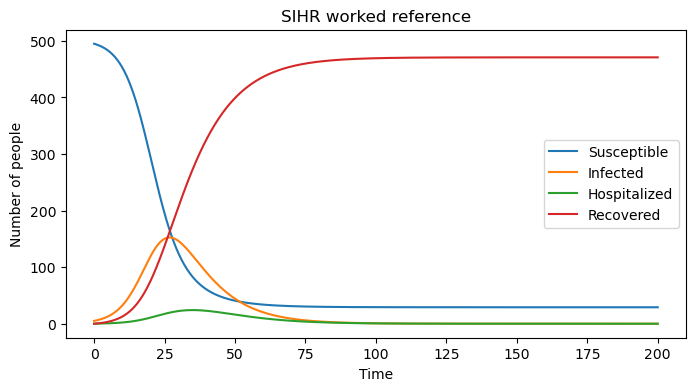

In [4]:
# SIHR: complete model. State order S, I, H, R.
# params: beta, alpha (rate leaving I), p_recover (fraction to R directly), eta (discharge)
def sihr_rhs(X, params):
    S, I, H, R = X
    N = S + I + H + R
    beta, alpha, p_recover, eta = params
    infection       = beta * S * I / N
    direct_recovery = alpha * p_recover * I
    hospitalization = alpha * (1 - p_recover) * I
    discharge       = eta * H
    dS = -infection
    dI =  infection - direct_recovery - hospitalization
    dH =  hospitalization - discharge          # in: alpha*(1 - p)*I,  out: eta*H
    dR =  direct_recovery + discharge          # alpha*p*I (direct) + eta*H (from H)
    return np.array([dS, dI, dH, dR])

ts, xs = simulate(sihr_rhs, np.array([495., 5., 0., 0.]), (0.3, 0.1, 0.8, 0.1))
print("SIHR: peak hospitalized =", round(xs[:, 2].max(), 1), "| population sum =", round(xs[-1].sum(), 1))
plt.figure(figsize=(8, 4))
plt.plot(ts, xs, label=['Susceptible', 'Infected', 'Hospitalized', 'Recovered'])
plt.xlabel("Time"); plt.ylabel("Number of people"); plt.title("SIHR worked reference")
plt.legend(); plt.show()

## Exercise 3: scenario visualization

The blank in the participant cell should be the peak-infected column: `scenario_df["peak_infected"]`. The bar chart then shows how the peak climbs as the transmission rate $\beta$ rises.

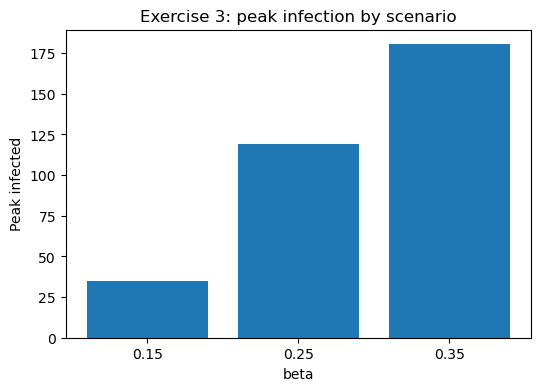

,beta,peak_infected,day_of_peak
0,0.15,34.911675,65.2
1,0.25,119.132111,33.2
2,0.35,180.408334,22.5


In [5]:
# Mirror the participant flow: build scenario_rows with simulate(), then the filled-in bar chart.
def sir_rhs_day2(X, params):
    S, I, R = X
    N = S + I + R
    beta, gamma = params
    return np.array([-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I])

scenario_rows = []
for beta_value in [0.15, 0.25, 0.35]:
    ts, sol = simulate(sir_rhs_day2, np.array([495., 5., 0.]), (beta_value, 0.1), days=100)
    scenario_rows.append({"beta": beta_value,
                          "peak_infected": sol[:, 1].max(),
                          "day_of_peak": ts[sol[:, 1].argmax()]})
scenario_df = pd.DataFrame(scenario_rows)

plt.figure(figsize=(6, 4))
plt.bar(scenario_df["beta"].astype(str), scenario_df["peak_infected"])   # the filled-in blank
plt.xlabel("beta"); plt.ylabel("Peak infected"); plt.title("Exercise 3: peak infection by scenario")
plt.show()
scenario_df